In [ ]:

# import pandas as pd
# url = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
# df = pd.read_csv(url, compression="zip", encoding="latin1")

In [ ]:
df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [ ]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
df.shape

(8760, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [ ]:
import io, re, zipfile, urllib.request
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

SEED, N_BOOT = 42, 5000
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

R1: Question

In [ ]:
QUESTION = ("Do public holidays have fewer bike rentals per day than non-holidays, "
            "by enough to justify a reduced bike-supply schedule on holidays?")
print(QUESTION)

Do public holidays have fewer bike rentals per day than non-holidays, by enough to justify a reduced bike-supply schedule on holidays?


R2: Data and quality audit


In [ ]:
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"

def load_seoul(url=URL):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
    csv_name = next(n for n in z.namelist() if n.lower().endswith(".csv"))
    return pd.read_csv(z.open(csv_name), encoding="latin1")

norm = lambda c: re.sub(r"[^a-z0-9]+", "_", str(c).lower()).strip("_")

df = load_seoul()
df.columns = [norm(c) for c in df.columns]
assert {"date", "rented_bike_count", "hour", "seasons", "holiday", "functioning_day"} <= set(df.columns)
temp_col = next(c for c in df.columns if c.startswith("temperature"))

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df["is_holiday"] = df["holiday"].astype(str).str.strip().str.lower().eq("holiday")
df["functioning"] = df["functioning_day"].astype(str).str.strip().str.lower().eq("yes")
df["temp"] = df[temp_col]

print("rows, cols:", df.shape, "| one row = one hour")
print("date range:", df["date"].min().date(), "->", df["date"].max().date())
print("rows per day:", df.groupby("date").size().value_counts().to_dict())
print("missing values:", int(df.isna().sum().sum()))
print("holiday hours:", int(df["is_holiday"].sum()), "| holiday days:", df.loc[df["is_holiday"], "date"].nunique())
print("non-functioning hours:", int((~df["functioning"]).sum()))
print(df.groupby("functioning")["rented_bike_count"].agg(["count", "mean", "min", "max"]))

rows, cols: (8760, 17) | one row = one hour
date range: 2017-12-01 -> 2018-11-30
rows per day: {24: 365}
missing values: 0
holiday hours: 432 | holiday days: 18
non-functioning hours: 295
             count   mean  min   max
functioning                         
False          295   0.00    0     0
True          8465 729.16    2  3556


R3: Headline comparison (daily unit, naive gap, 95% CI)


days: 365 | kept: 352 | excluded: 13
      group  days      mean        sd
    Holiday    17 12,699.71 10,504.34
Non-holiday   335 17,732.48  9,876.74

NAIVE: -5,033 trips/day (95% CI -10,516 to 450)
Relative: -28.4% (95% CI -59.3% to +2.5%)


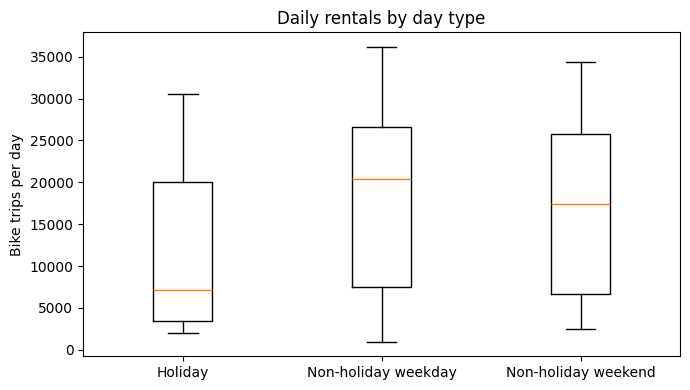

In [ ]:
g = df.groupby("date")
daily = pd.DataFrame({
    "total": g["rented_bike_count"].sum(),
    "n_func": g["functioning"].sum(),
    "holiday": g["is_holiday"].max(),
    "season": g["seasons"].first(),
    "temp": g["temp"].mean(),
})
daily["weekend"] = daily.index.dayofweek >= 5
daily["month"] = daily.index.month
daily["complete"] = daily["n_func"] == 24

d = daily[daily["complete"]].copy()          # drop days when the system was down
d["day_type"] = np.where(d["holiday"], "Holiday", np.where(d["weekend"], "Non-holiday weekend", "Non-holiday weekday"))
print("days:", len(daily), "| kept:", len(d), "| excluded:", (~daily["complete"]).sum())

def welch(h, n):
    vh, vn = h.var(ddof=1)/len(h), n.var(ddof=1)/len(n)
    diff, se = h.mean()-n.mean(), np.sqrt(vh+vn)
    dof = (vh+vn)**2 / (vh**2/(len(h)-1) + vn**2/(len(n)-1))
    t = stats.t.ppf(0.975, dof)
    return diff, diff-t*se, diff+t*se

h = d.loc[d["holiday"], "total"].to_numpy()
n = d.loc[~d["holiday"], "total"].to_numpy()
print(pd.DataFrame({"group": ["Holiday", "Non-holiday"], "days": [len(h), len(n)],
                    "mean": [h.mean(), n.mean()], "sd": [h.std(ddof=1), n.std(ddof=1)]}).to_string(index=False))

naive, naive_lo, naive_hi = welch(h, n)
base = n.mean()
print(f"\nNAIVE: {naive:,.0f} trips/day (95% CI {naive_lo:,.0f} to {naive_hi:,.0f})")
print(f"Relative: {naive/base:+.1%} (95% CI {naive_lo/base:+.1%} to {naive_hi/base:+.1%})")

order = ["Holiday", "Non-holiday weekday", "Non-holiday weekend"]
fig, ax = plt.subplots(figsize=(7, 4))
data = [d.loc[d["day_type"] == k, "total"] for k in order]
ax.boxplot(data, showfliers=False)
ax.set_xticks(range(1, 4)); ax.set_xticklabels(order)
ax.set_ylabel("Bike trips per day"); ax.set_title("Daily rentals by day type")
plt.tight_layout(); plt.show()

R4: Rule out chance, confounding, artefact

In [ ]:
# --- Chance
print("Naive CI excludes zero:", not (naive_lo <= 0 <= naive_hi))

# --- Confounding: do the groups differ?
lab = d["holiday"].map({False: "Non-holiday", True: "Holiday"})
print(pd.DataFrame({"share weekend": d.groupby(lab)["weekend"].mean(),
                    "mean temp (C)": d.groupby(lab)["temp"].mean()}))
print("\nSeason mix:\n", pd.crosstab(lab, d["season"], normalize="index"))
print("\nMean trips by weekend x holiday:\n", d.pivot_table(index="weekend", columns="holiday", values="total", aggfunc=["mean", "count"]))

# --- Control by stratifying (weighted by holiday days per stratum) + bootstrap CI
def adjusted_diff(data, strata, n_boot=N_BOOT, seed=SEED):
    r = np.random.default_rng(seed)
    strata = [strata] if isinstance(strata, str) else list(strata)
    cells = []
    for _, gg in data.groupby(strata, observed=True):
        hh = gg.loc[gg["holiday"], "total"].to_numpy()
        nn = gg.loc[~gg["holiday"], "total"].to_numpy()
        if len(hh) > 0 and len(nn) > 0:
            cells.append((hh, nn))
    w = np.array([len(hh) for hh, _ in cells], float); W = w.sum()
    est = sum(wi*(hh.mean()-nn.mean()) for wi, (hh, nn) in zip(w, cells)) / W
    baseline = sum(wi*nn.mean() for wi, (_, nn) in zip(w, cells)) / W
    boots = np.zeros(n_boot)
    for wi, (hh, nn) in zip(w, cells):
        boots += wi*(r.choice(hh, (n_boot, len(hh))).mean(1) - r.choice(nn, (n_boot, len(nn))).mean(1))
    lo, hi = np.percentile(boots/W, [2.5, 97.5])
    return {"est": est, "lo": lo, "hi": hi, "baseline": baseline, "rel": est/baseline,
            "strata_used": len(cells), "holiday_days_used": int(W), "holiday_days_total": int(data["holiday"].sum())}

main = adjusted_diff(d, ["weekend", "season"])
print(f"\nCONTROLLED: {main['est']:,.0f} trips/day (95% CI {main['lo']:,.0f} to {main['hi']:,.0f}), {main['rel']:+.1%}")
print(f"strata used: {main['strata_used']} | holiday days used: {main['holiday_days_used']} of {main['holiday_days_total']}")
print(pd.DataFrame({"estimate": [naive, main["est"]], "CI low": [naive_lo, main["lo"]],
                    "CI high": [naive_hi, main["hi"]], "relative": [naive/base, main["rel"]]},
                   index=["Naive", "Controlled (weekend x season)"]))
print(f"Controlling moved the estimate by {main['est']-naive:+,.0f} trips/day.")

# --- Artefact
print("\nExcluded days by group:\n", daily.assign(excluded=~daily["complete"]).groupby("holiday")["excluded"].agg(["sum", "count"]))
print("\nHoliday days per month:\n", d.loc[d["holiday"], "month"].value_counts().sort_index().to_string())
print("\nMeasurement method: cannot be checked from this data (not documented).")

Naive CI excludes zero: False
             share weekend  mean temp (C)
holiday                                  
Holiday               0.24           9.65
Non-holiday           0.29          12.92

Season mix:
 season       Autumn  Spring  Summer  Winter
holiday                                    
Holiday        0.24    0.18    0.12    0.47
Non-holiday    0.23    0.26    0.27    0.24

Mean trips by weekend x holiday:
              mean           count      
holiday     False     True  False True 
weekend                                
False   18,148.52 14,406.15   238    13
True    16,711.69  7,153.75    97     4

CONTROLLED: -1,362 trips/day (95% CI -3,648 to 1,023), -9.7%
strata used: 6 | holiday days used: 17 of 17
                               estimate     CI low  CI high  relative
Naive                         -5,032.78 -10,516.01   450.45     -0.28
Controlled (weekend x season) -1,361.85  -3,647.86 1,023.10     -0.10
Controlling moved the estimate by +3,671 trips/day.

Exclude

R5: Sensitivity

                                      est        lo        hi   rel  \
scenario                                                              
S1 weekend x season (main)      -1,361.85 -3,647.86  1,023.10 -0.10   
S2 weekend only                 -5,110.74 -9,696.71   -359.63 -0.29   
S3 weekend x temp terciles      -1,397.69 -3,401.72    552.48 -0.10   
S4 weekend x temp halves        -4,652.81 -6,695.02 -2,630.40 -0.27   
S5 weekdays only, by season     -1,257.05 -4,216.75  1,841.29 -0.08   
S6 main strata, no outlier days -1,361.85 -3,647.86  1,023.10 -0.10   

                                 holiday days used  
scenario                                            
S1 weekend x season (main)                      17  
S2 weekend only                                 17  
S3 weekend x temp terciles                      17  
S4 weekend x temp halves                        17  
S5 weekdays only, by season                     13  
S6 main strata, no outlier days                 17  

Range:

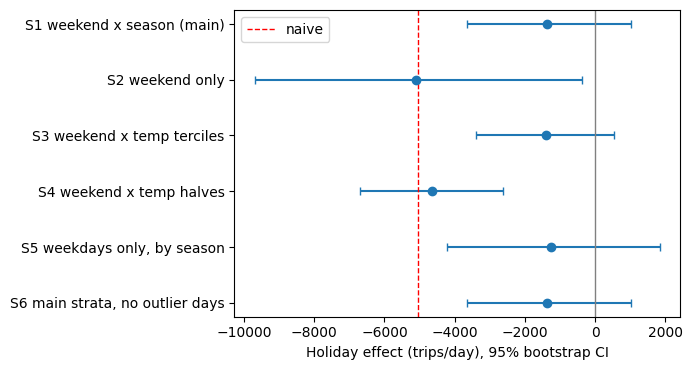

In [ ]:
d["temp_terc"] = pd.qcut(d["temp"], 3, labels=False)
d["temp_half"] = pd.qcut(d["temp"], 2, labels=False)
q1, q3 = d["total"].quantile([0.25, 0.75]); iqr = q3 - q1
no_out = d[d["total"].between(q1 - 1.5*iqr, q3 + 1.5*iqr)]

specs = {
    "S1 weekend x season (main)":     (d, ["weekend", "season"]),
    "S2 weekend only":                (d, ["weekend"]),
    "S3 weekend x temp terciles":     (d, ["weekend", "temp_terc"]),
    "S4 weekend x temp halves":       (d, ["weekend", "temp_half"]),
    "S5 weekdays only, by season":    (d[~d["weekend"]], ["season"]),
    "S6 main strata, no outlier days": (no_out, ["weekend", "season"]),
}
rows = []
for name, (data, strata) in specs.items():
    r_ = adjusted_diff(data, strata)
    rows.append({"scenario": name, "est": r_["est"], "lo": r_["lo"], "hi": r_["hi"],
                 "rel": r_["rel"], "holiday days used": r_["holiday_days_used"]})
sens = pd.DataFrame(rows).set_index("scenario")
print(sens)
print(f"\nRange: {sens['est'].min():,.0f} to {sens['est'].max():,.0f} trips/day")

fig, ax = plt.subplots(figsize=(7, 3.8))
y = np.arange(len(sens))[::-1]
ax.errorbar(sens["est"], y, xerr=[sens["est"]-sens["lo"], sens["hi"]-sens["est"]], fmt="o", capsize=3)
ax.axvline(0, color="grey", lw=1); ax.axvline(naive, color="red", ls="--", lw=1, label="naive")
ax.set_yticks(y); ax.set_yticklabels(sens.index)
ax.set_xlabel("Holiday effect (trips/day), 95% bootstrap CI"); ax.legend()
plt.tight_layout(); plt.show()

R6: Write-up (no analysis code, just a word-count check)

In [ ]:
# Fill REPORT.md, then check length (target 800-1,500 words)
#/content/REPORT1.md
import re
text = open("REPORT1.md", encoding="utf-8").read()
text = re.sub(r"<!--.*?-->", "", text, flags=re.S)
print("words:", len(text.split()))

words: 1344


R7: Memorable number

In [ ]:
direction = "fewer" if main["est"] < 0 else "more"
print(f"MEMORABLE NUMBER: On a public holiday, Seoul sees about {abs(main['est']):,.0f} {direction} bike trips per day "
      f"than on comparable non-holidays (95% CI {abs(main['hi']):,.0f} to {abs(main['lo']):,.0f} {direction}; "
      f"{abs(main['rel']):.0%} {direction}).")

MEMORABLE NUMBER: On a public holiday, Seoul sees about 1,362 fewer bike trips per day than on comparable non-holidays (95% CI 1,023 to 3,648 fewer; 10% fewer).


R8: Stretch (bootstrap vs formula, sample size)

In [ ]:
boot = np.array([rng.choice(h, len(h)).mean() - rng.choice(n, len(n)).mean() for _ in range(N_BOOT)])
b_lo, b_hi = np.percentile(boot, [2.5, 97.5])
print(f"Naive CI  Welch: [{naive_lo:,.0f}, {naive_hi:,.0f}]  Bootstrap: [{b_lo:,.0f}, {b_hi:,.0f}]")

sd = np.sqrt((h.var(ddof=1) + n.var(ddof=1)) / 2)
delta_half = abs(main["est"]) / 2
n_needed = 2 * ((stats.norm.ppf(0.975) + stats.norm.ppf(0.80)) * sd / delta_half) ** 2
print(f"To detect half the controlled effect ({delta_half:,.0f} trips/day): ~{n_needed:,.0f} holiday days "
      f"and as many comparison days (rough; pooled SD {sd:,.0f}, ignores stratification).")

Naive CI  Welch: [-10,516, 450]  Bootstrap: [-9,823, 227]
To detect half the controlled effect (681 trips/day): ~3,519 holiday days and as many comparison days (rough; pooled SD 10,195, ignores stratification).
